Importing all necessary libraries to perform the tasks given in Hero FinCorp Case Study

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
print("\nAll librares are successfully imported")


All librares are successfully imported


1. Data Quality and Preparation
- Validate and clean the datasets.
- Check for missing values, duplicate entries, and inconsistent data.
- Standardize date formats and remove irrelevant columns.
- Handle outliers in numeric columns like Loan_Amount, Interest_Rate, and Default_Amount.

In [2]:
# File paths
files = {
    "branches": "C:\\Users\\nshetty7\\OneDrive - DXC Production\\05.Learning\\01.HeroVired\\ABADS 20\\Assignment\\Graded\\Python\\Hero_FinCorp_Case_Study\\Datasets\\branches.csv",
    "customers": "C:\\Users\\nshetty7\\OneDrive - DXC Production\\05.Learning\\01.HeroVired\\ABADS 20\\Assignment\\Graded\\Python\\Hero_FinCorp_Case_Study\\Datasets\\customers.csv",
    "defaults": "C:\\Users\\nshetty7\\OneDrive - DXC Production\\05.Learning\\01.HeroVired\\ABADS 20\\Assignment\\Graded\\Python\\Hero_FinCorp_Case_Study\\Datasets\\defaults.csv",
    "loans": "C:\\Users\\nshetty7\\OneDrive - DXC Production\\05.Learning\\01.HeroVired\\ABADS 20\\Assignment\\Graded\\Python\\Hero_FinCorp_Case_Study\\Datasets\\loans.csv",
    "transactions": "C:\\Users\\nshetty7\\OneDrive - DXC Production\\05.Learning\\01.HeroVired\\ABADS 20\\Assignment\\Graded\\Python\\Hero_FinCorp_Case_Study\\Datasets\\transactions.csv",
    "applications": "C:\\Users\\nshetty7\\OneDrive - DXC Production\\05.Learning\\01.HeroVired\\ABADS 20\\Assignment\\Graded\\Python\\Hero_FinCorp_Case_Study\\Datasets\\applications.csv"
}

# Function to clean individual DataFrames
def clean_dataframe(df):
    # 1. Remove duplicates
    df = df.drop_duplicates()
    
    # 2. Handle missing values
    # Fill numeric columns with median, categorical with mode
    
    for col in df.columns:
        if df[col].isna().any():
            if df[col].dtype in [np.float64, np.int64]:
                df[col] = df[col].fillna(df[col].median())
            else:
                df[col] = df[col].fillna(df[col].mode()[0])
                
    # 3. Standardize date columns
    for col in df.columns:
        if "date" in col.lower():
            df[col] = pd.to_datetime(df[col], errors='coerce')
    

    # 4. Remove irrelevant columns (like unnamed index columns)
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    return df

# Load and clean all datasets
cleaned_dfs = {}
for name, path in files.items():
    df = pd.read_csv(path,low_memory=False)
    cleaned_df = clean_dataframe(df)
    cleaned_dfs[name] = cleaned_df


# Handle outliers for specific numeric columns in loans and default dataset
if "loans" in cleaned_dfs:
    for col in ["Loan_Amount", "Interest_Rate", "Default_Amount"]:
        if col in cleaned_dfs["loans"].columns:
            q1 = cleaned_dfs["loans"][col].quantile(0.25)
            q3 = cleaned_dfs["loans"][col].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            # Clip values outside the whisker range
            cleaned_dfs["loans"][col] = cleaned_dfs["loans"][col].clip(lower=lower_bound, upper=upper_bound)

# Quick overview of cleaned datasets
for name, df in cleaned_dfs.items():
    print(f"{name.upper()} dataset after cleaning:")
    print(df.info())
    print(df.head())

BRANCHES dataset after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Branch_ID                   50 non-null     object
 1   Branch_Name                 50 non-null     object
 2   Region                      50 non-null     object
 3   Total_Customers             50 non-null     int64 
 4   Total_Active_Loans          50 non-null     int64 
 5   Delinquent_Loans            50 non-null     int64 
 6   Loan_Disbursement_Amount    50 non-null     int64 
 7   Avg_Processing_Time         50 non-null     int64 
 8   Relationship_Manager_Count  50 non-null     int64 
dtypes: int64(6), object(3)
memory usage: 3.6+ KB
None
  Branch_ID             Branch_Name   Region  Total_Customers  \
0      B001    Dhar, Kant and Madan     West             2891   
1      B002              Shan Group     East             4459   

Assigning names to all our cleaned datasets to use for our Data Analysis

In [3]:

applications =cleaned_dfs["applications"]
loans =cleaned_dfs["loans"]
customers =cleaned_dfs["customers"]
defaults =cleaned_dfs["defaults"]
transactions =cleaned_dfs["transactions"]
branches =cleaned_dfs["branches"]


2. Descriptive Analysis
- Summarize and visualize key metrics:
    - Distribution of Loan_Amount, EMI_Amount, and Credit_Score.
    - Regional trends in loan disbursement and defaults.
    - Monthly trends in loan approvals and disbursements.

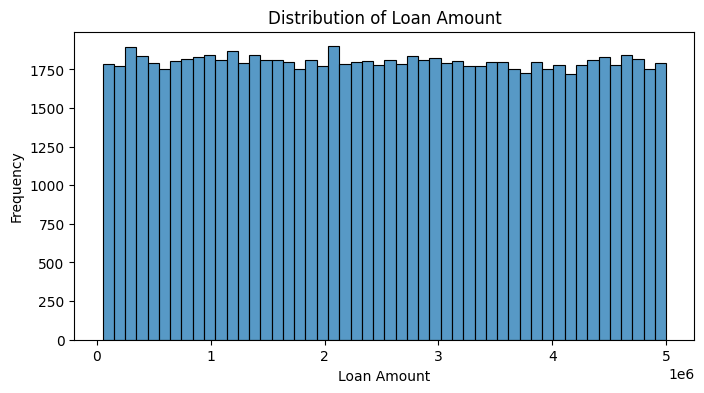

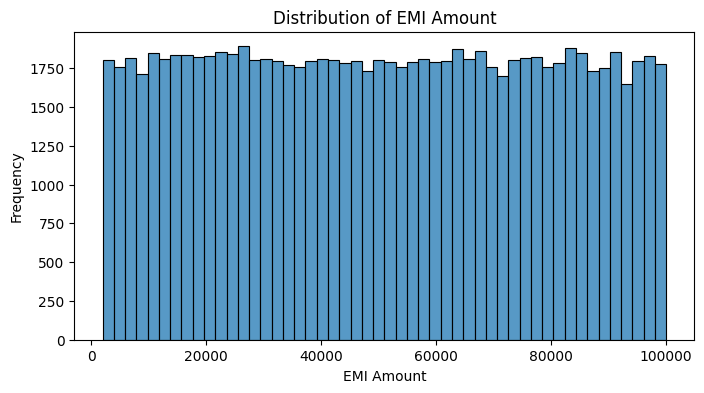

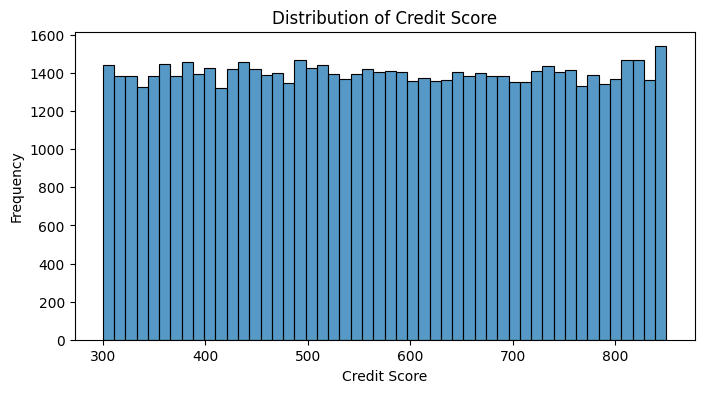

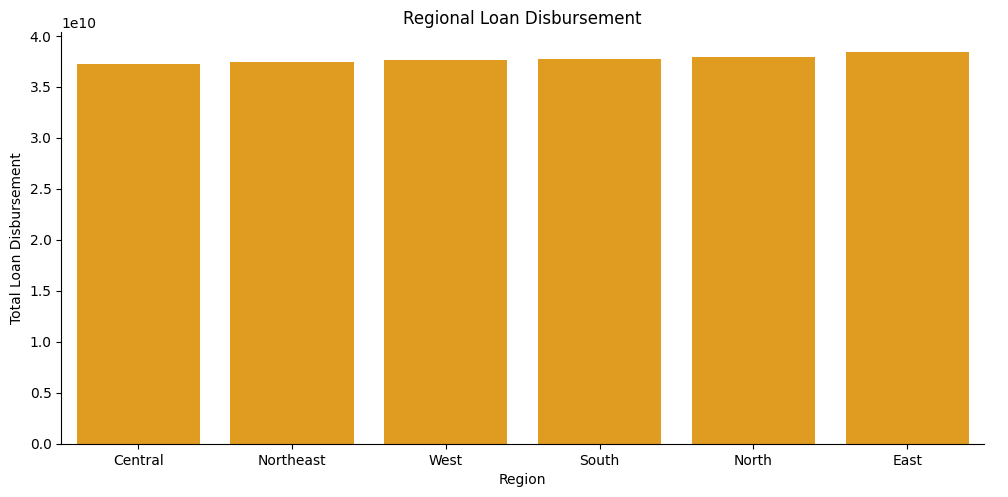

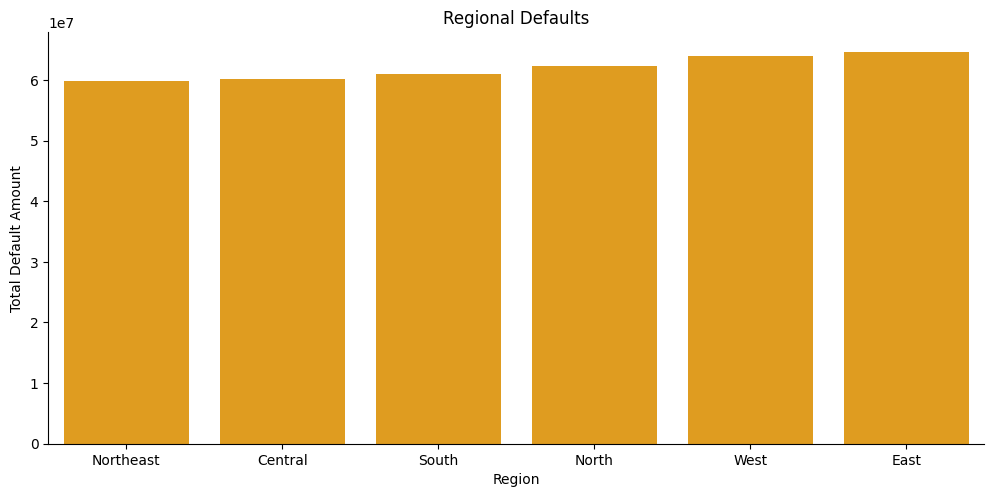

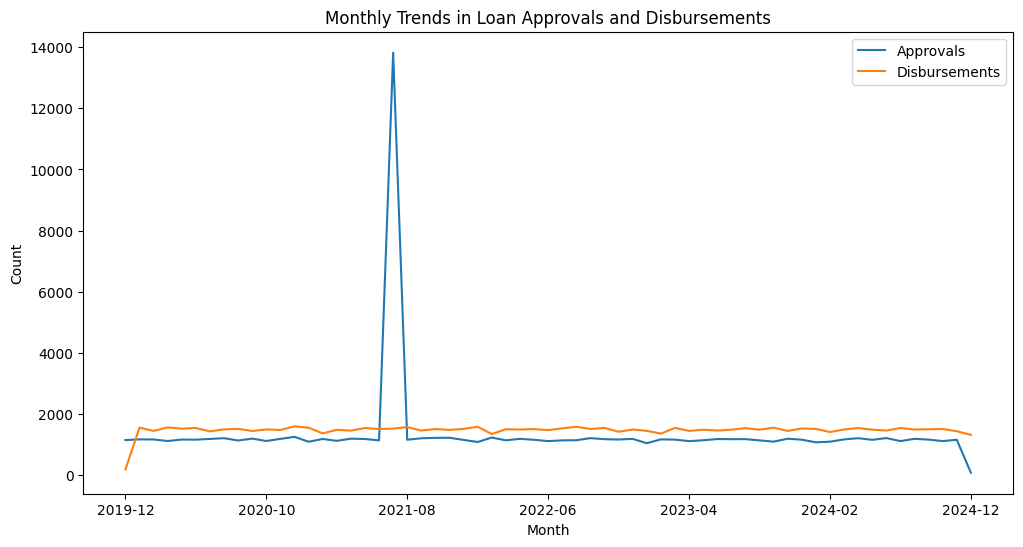

In [4]:
# --- Distribution of Loan_Amount, EMI_Amount, and Credit_Score ---
plt.figure(figsize=(8, 4))
sns.histplot(loans["Loan_Amount"], bins=50)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(8, 4))
sns.histplot(loans["EMI_Amount"], bins=50)
plt.title("Distribution of EMI Amount")
plt.xlabel("EMI Amount")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(8, 4))
sns.histplot(customers["Credit_Score"], bins=50)
plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()

# --- Regional trends in loan disbursement and defaults ---
loans_customers = loans.merge(customers[["Customer_ID", "Region"]], on="Customer_ID", how="left")
regional_disbursement = loans_customers.groupby("Region")["Loan_Amount"].sum().sort_values()

default_customers = defaults.merge(customers[["Customer_ID", "Region"]], on="Customer_ID", how="left")
regional_defaults = default_customers.groupby("Region")["Default_Amount"].sum().sort_values()

regional_disbursement_df = pd.DataFrame(regional_disbursement)
regional_defaults_df = pd.DataFrame(regional_defaults)


sns.catplot(regional_disbursement_df, x= "Region",y="Loan_Amount",kind="bar",color="orange",height=5,aspect=2)
#plt.figure(figsize=(10, 5))
plt.title("Regional Loan Disbursement")
plt.xlabel("Region")
plt.ylabel("Total Loan Disbursement")
plt.show()

sns.catplot(regional_defaults_df, x= "Region",y="Default_Amount",kind="bar",color="orange",height=5,aspect=2)
#plt.figure(figsize=(10, 5))
plt.title("Regional Defaults")
plt.xlabel("Region")
plt.ylabel("Total Default Amount")
plt.show()


# --- Monthly trends in loan approvals and disbursements ---
applications["Month"] = applications["Approval_Date"].dt.to_period("M").astype(str)
#-----------------------------------------------------------------------------------------------------------------------------
#loans["Month"] = loans["Disbursal_Date"].dt.to_period("M").astype(str)
loans_customers["Month"] = loans_customers["Disbursal_Date"].dt.to_period("M").astype(str)
#-----------------------------------------------------------------------------------------------------------------------------


monthly_approvals = applications.groupby("Month")["Approval_Status"].count()
#-----------------------------------------------------------------------------------------------------------------------------
#monthly_disbursements = loans.groupby("Month")["Loan_ID"].count()
monthly_disbursements = loans_customers.groupby("Month")["Loan_ID"].count()
#-----------------------------------------------------------------------------------------------------------------------------


plt.figure(figsize=(12, 6))
monthly_approvals.plot(label="Approvals")
monthly_disbursements.plot(label="Disbursements")
plt.title("Monthly Trends in Loan Approvals and Disbursements")
plt.xlabel("Month")
plt.ylabel("Count")
plt.legend()
plt.show()

3. Default Risk Analysis
- Correlation Between Loan Attributes and Defaults:
    - Calculate correlations between Loan_Amount, Interest_Rate, Credit_Score, and Default_Flag (a binary indicator for default).
- Pairwise Correlation Analysis:
    - Create a heatmap to visualize the correlations between key variables, such as EMI_Amount, Overdue_Amount, and Default_Amount.
- Correlation Between Branch Metrics and Defaults:
    - Analyze the relationship between branch performance metrics (e.g., Delinquent_Loans, Loan_Disbursement_Amount) and default rates.


Correlation between Loan Attributes and Defaults:
               Loan_Amount  Interest_Rate  Credit_Score  Default_Flag
Loan_Amount       1.000000      -0.003201      0.000139     -0.003313
Interest_Rate    -0.003201       1.000000      0.002457     -0.003750
Credit_Score      0.000139       0.002457      1.000000     -0.001580
Default_Flag     -0.003313      -0.003750     -0.001580      1.000000


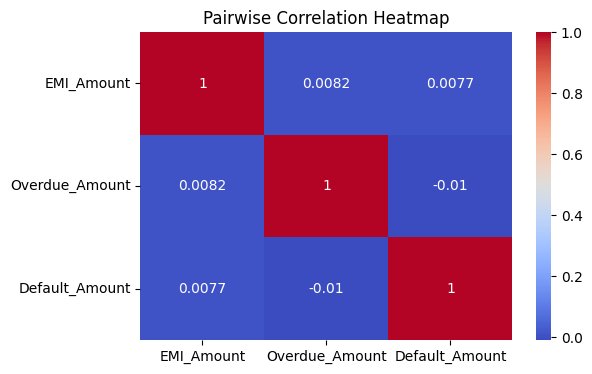


Correlation between Branch Metrics and Default Rates:
                            Default_Rate
Total_Customers                -0.051352
Total_Active_Loans              0.135309
Delinquent_Loans               -0.060002
Loan_Disbursement_Amount        0.061403
Avg_Processing_Time            -0.244240
Relationship_Manager_Count     -0.124096
Default_Rate                    1.000000


In [5]:
# --- Correlation Between Loan Attributes and Defaults ---
# Add a binary Default_Flag to loans
#-----------------------------------------------------------------------------------------------------------------------------
#loans["Default_Flag"] = loans["Loan_ID"].isin(defaults["Loan_ID"]).astype(int)
loans_customers["Default_Flag"] = loans_customers["Loan_ID"].isin(defaults["Loan_ID"]).astype(int)

#-----------------------------------------------------------------------------------------------------------------------------

# Merge to bring in Credit_Score

#-----------------------------------------------------------------------------------------------------------------------------
#loan_data = loans.merge(customers[["Customer_ID", "Credit_Score"]], on="Customer_ID", how="left")
loans_customers = loans_customers.merge(customers[["Customer_ID", "Credit_Score"]], on="Customer_ID", how="left")
#-----------------------------------------------------------------------------------------------------------------------------

# Calculate correlations
corr_data = loans_customers[["Loan_Amount", "Interest_Rate", "Credit_Score", "Default_Flag"]].corr()
print("Correlation between Loan Attributes and Defaults:")
print(corr_data)

# --- Pairwise Correlation Analysis (Heatmap) ---
# Combine default info with loan attributes

#-----------------------------------------------------------------------------------------------------------------------------
#default_loan = defaults.merge(loans[["Loan_ID", "EMI_Amount", "Overdue_Amount"]],on="Loan_ID", how="left")
default_loan = defaults.merge(loans_customers[["Loan_ID", "EMI_Amount", "Overdue_Amount"]],on="Loan_ID", how="left")
#-----------------------------------------------------------------------------------------------------------------------------

pairwise_data = default_loan[["EMI_Amount", "Overdue_Amount", "Default_Amount"]]

plt.figure(figsize=(6, 4))
sns.heatmap(pairwise_data.corr(), annot=True, cmap="coolwarm")
plt.title("Pairwise Correlation Heatmap")
plt.show()

# --- Correlation Between Branch Metrics and Defaults ---
# Link loans → customers (region) → branches

#-----------------------------------------------------------------------------------------------------------------------------
#loan_customer = loan_data.merge(customers[["Customer_ID", "Region"]], on="Customer_ID", how="left")
loan_customer_branch = loans_customers.merge(branches, on="Region", how="left")
#-----------------------------------------------------------------------------------------------------------------------------

# Compute default rates per branch
branch_default_counts = loan_customer_branch.groupby("Branch_Name")["Default_Flag"].mean()

# Converting branch_default_counts  into a DataFrame with Branch_Name as a column
branch_default_df = branch_default_counts.reset_index()
branch_default_df.columns = ["Branch_Name", "Default_Rate"]

# Then merge on the Branch_Name column
branch_analysis = branches.merge(branch_default_df, on="Branch_Name", how="left")

# Correlation matrix focusing on default rate
branch_corr = branch_analysis.corr(numeric_only=True)

print("\nCorrelation between Branch Metrics and Default Rates:")
print(branch_corr[["Default_Rate"]])

4. Branch and Regional Performance
- Rank branches by:
    - Loan disbursement volume.
    - Processing time effi ciency.
    - Default rates and recovery rates.
- Compare branch performance across regions.


In [6]:
# --- Rank branches by loan disbursement volume ---
branch_loan_volume = loan_customer_branch.groupby("Branch_Name")["Loan_Amount"].sum().sort_values(ascending=False)
print("\nBranches ranked by Loan Disbursement Volume:")
print(branch_loan_volume)


# --- Rank branches by processing time efficiency (lower is better) ---
processing_efficiency = branches[["Branch_Name", "Avg_Processing_Time"]].sort_values(by="Avg_Processing_Time")
print("\nBranches ranked by Processing Time Efficiency:")
print(processing_efficiency)

# --- Rank branches by default rates ---
branch_default_rates = loan_customer_branch.groupby("Branch_Name")["Default_Flag"].mean().sort_values(ascending=False)
print("\nBranches ranked by Default Rates:")
print(branch_default_rates)

# --- Rank branches by recovery rates ---
# Compute total defaults and recovery per branch
default_loan_customer = default_loan.merge(customers[["Customer_ID", "Region"]], on="Customer_ID", how="left")
default_loan_customer_branch = default_loan_customer.merge(branches, on="Region", how="left")


# --- Rank branches by recovery rates ---
# Group once and compute 
branch_sums = (
    default_loan_customer_branch
    .groupby("Branch_Name")[["Recovery_Amount", "Default_Amount"]]
    .sum()
)

# Compute recovery rate safely (avoid division by zero)
branch_sums["Recovery_Rate"] = branch_sums["Recovery_Amount"] / branch_sums["Default_Amount"].replace(0, pd.NA)
# Sort by recovery rate in descending order (highest first)
branch_recovery_rate = branch_sums["Recovery_Rate"].sort_values(ascending=False)


print("\nBranches ranked by Recovery Rates:")
print(branch_recovery_rate)

# --- Compare branch performance across regions ---
region_summary = loan_customer_branch.groupby("Region").agg(
    Total_Loan_Disbursement=("Loan_Amount", "sum"),
    Avg_Processing_Time=("Avg_Processing_Time", "mean"),
    Default_Rate=("Default_Flag", "mean")
).sort_values(by="Total_Loan_Disbursement", ascending=False)

print("\nBranch Performance Across Regions:")
print(region_summary)


Branches ranked by Loan Disbursement Volume:
Branch_Name
Bhatnagar, Khalsa and Savant    38437798746
Bansal, Arya and Chakrabarti    38437798746
Chawla-Tandon                   38437798746
Grover Group                    38437798746
Kapadia-Brar                    38437798746
Shan Group                      38437798746
Kara-Bahl                       38437798746
Kakar-Dutta                     38437798746
Dada, Chander and Bhatt         37963952967
Apte Group                      37963952967
Madan-Lanka                     37963952967
Khalsa, Mani and Banik          37963952967
Lad, Wali and Ramesh            37963952967
Bath-Bassi                      37963952967
Bhatti, Rau and Sem             37963952967
Dhingra Ltd                     37963952967
Doshi Group                     37963952967
Banik, Subramanian and Mane     37963952967
Yogi Ltd                        37963952967
Vasa Group                      37963952967
Sani-Kale                       37963952967
Doshi LLC         

5. Customer Segmentation
- Segment customers by income, credit score, and loan status.
- Identify high-risk and high-value customer groups.
- Analyze repayment behavior across segments.


In [7]:
# Merge customers with their loan info
#-----------------------------------------------------------------------------------------------------------------------------
#cust_loan = loans.merge(customers, on="Customer_ID", how="left")
cust_loan = customers.merge(loans_customers[["Customer_ID","Default_Flag","Loan_Status","Loan_Amount","Overdue_Amount","Interest_Rate"]], on="Customer_ID", how="left")
#--------------------------------------------------------------p---------------------------------------------------------------

# --- Segment customers by income ---
cust_loan["Income_Segment"] = pd.cut(cust_loan["Annual_Income"],
    #bins=[0, 100000, 700000, 1500000, float("inf")],
    bins = 4,
    labels=["Low", "Medium", "High", "Very High"]
)

# --- Segment customers by credit score ---
cust_loan["Credit_Segment"] = pd.cut(cust_loan["Credit_Score"],
    #bins=[0, 600, 750, 850, float("inf")],
    bins = 4,
    labels=["Poor", "Fair", "Good", "Excellent"]
)

# --- Identify high-risk and high-value groups ---

# Customer who are defaults are considered as High Risk
high_risk = cust_loan[cust_loan["Loan_Status"] == "Overdue"]

# Customer who are having good credeit score and annual income are considered as High Value
high_value = cust_loan[(cust_loan["Credit_Score"] > 750) & (cust_loan["Annual_Income"] > 100000)]

print("\nHigh-Risk Customers (Defaults):")
print(high_risk[["Customer_ID", "Annual_Income", "Credit_Score", "Loan_Status"]])

print("\nHigh-Value Customers (High income & excellent credit):")
print(high_value[["Customer_ID", "Annual_Income", "Credit_Score", "Loan_Status"]])

# --- Analyze repayment behavior across segments ---
repayment_summary = (cust_loan.groupby(["Income_Segment", "Credit_Segment", "Loan_Status"], observed = True).size())


print("\nRepayment Behavior Across Segments:")
print(repayment_summary)


High-Risk Customers (Defaults):
       Customer_ID  Annual_Income  Credit_Score Loan_Status
3          C000003        1118591           736     Overdue
5          C000004         524075           353     Overdue
9          C000007        1237215           548     Overdue
10         C000007        1237215           548     Overdue
11         C000008        1894653           648     Overdue
...            ...            ...           ...         ...
109301     C069983         278513           763     Overdue
109304     C069986        1677836           703     Overdue
109309     C069989        1488808           797     Overdue
109311     C069990        1680700           723     Overdue
109319     C069998         464958           629     Overdue

[29866 rows x 4 columns]

High-Value Customers (High income & excellent credit):
       Customer_ID  Annual_Income  Credit_Score Loan_Status
13         C000010        1734948           789         NaN
26         C000017        1776242           7

6. Advanced Statistical Analysis
- Correlation Analysis for Default Risks:
    - Examine the correlation between Credit_Score, Loan_Amount, Interest_Rate, Overdue_Amount, and Default_Flag.
- Pairwise Correlation Heatmap:
    - Generate a heatmap to visualize correlations among key variables like EMI_Amount, Recovery_Rate, and Default_Amount.
- Branch-Level Correlation:
    - Explore the relationship between branch performance metrics (Delinquent_Loans, Loan_Disbursement_Amount, Recovery_Rate) and overall efficiency.



Correlation between loan attributes and defaults:
                Credit_Score  Loan_Amount  Interest_Rate  Overdue_Amount  \
Credit_Score        1.000000     0.000139       0.002457        0.001570   
Loan_Amount         0.000139     1.000000      -0.003201        0.008400   
Interest_Rate       0.002457    -0.003201       1.000000       -0.002199   
Overdue_Amount      0.001570     0.008400      -0.002199        1.000000   
Default_Flag       -0.001580    -0.003313      -0.003750       -0.000687   

                Default_Flag  
Credit_Score       -0.001580  
Loan_Amount        -0.003313  
Interest_Rate      -0.003750  
Overdue_Amount     -0.000687  
Default_Flag        1.000000  


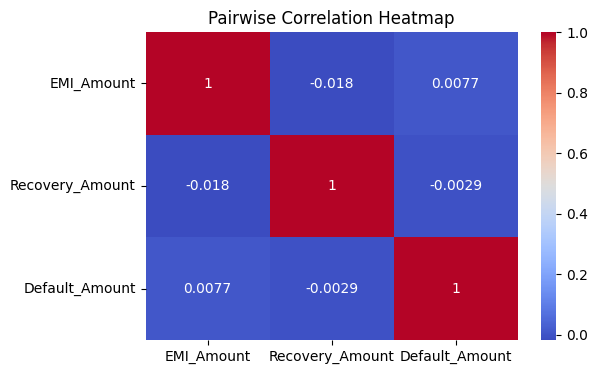


Branch-level performance correlations:
                          Loan_Disbursement_Amount  Delinquent_Loans  \
Loan_Disbursement_Amount                  1.000000         -0.536595   
Delinquent_Loans                         -0.536595          1.000000   
Recovery_Rate                            -0.195376          0.202469   

                          Recovery_Rate  
Loan_Disbursement_Amount      -0.195376  
Delinquent_Loans               0.202469  
Recovery_Rate                  1.000000  


In [8]:
# --- 1. Correlation Analysis for Default Risks ---
# Added  "Loan_Amount", "Interest_Rate", "Overdue_Amount"cols in previous task 

default_risk_cols = ["Credit_Score", "Loan_Amount", "Interest_Rate", "Overdue_Amount", "Default_Flag"]
default_risk_corr = cust_loan[default_risk_cols].corr()

print("\nCorrelation between loan attributes and defaults:")
print(default_risk_corr)

# --- 2. Pairwise Correlation Heatmap ---

heatmap_cols = ["EMI_Amount", "Recovery_Amount", "Default_Amount"]
plt.figure(figsize=(6, 4))
sns.heatmap(default_loan_customer[heatmap_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Pairwise Correlation Heatmap")
plt.show()

# --- 3. Branch-Level Correlation ---
# Group branch performance metrics
branch_metrics = (
    loan_customer_branch.groupby("Branch_Name")
    .agg({
        "Loan_Amount": "sum",
        "Default_Flag": "sum"
    })
    .rename(columns={
        "Loan_Amount": "Loan_Disbursement_Amount",
        "Default_Flag": "Delinquent_Loans"
    })
)

# Merge with branches for other metrics (e.g., Recovery_Rate if available)
branch_recovery_rate_df = pd.DataFrame(branch_recovery_rate)

branch_metrics = branch_metrics.join(branch_recovery_rate_df["Recovery_Rate"])

# Compute correlation between branch metrics
branch_corr = branch_metrics.corr()

print("\nBranch-level performance correlations:")
print(branch_corr)

7. Transaction and Recovery Analysis
- Analyze penalty payments and overdue trends.
- Evaluate recovery rates by Default_Reason and Legal_Action.
- Compare recovery rates across regions and branches.


Penalty/Overdue Trends by Month:
      Month  Penalty_Ratio
0   2019-12       0.012690
1   2020-01       0.012171
2   2020-02       0.010923
3   2020-03       0.009654
4   2020-04       0.012450
..      ...            ...
56  2024-08       0.010902
57  2024-09       0.010954
58  2024-10       0.013356
59  2024-11       0.011099
60  2024-12       0.011094

[61 rows x 2 columns]


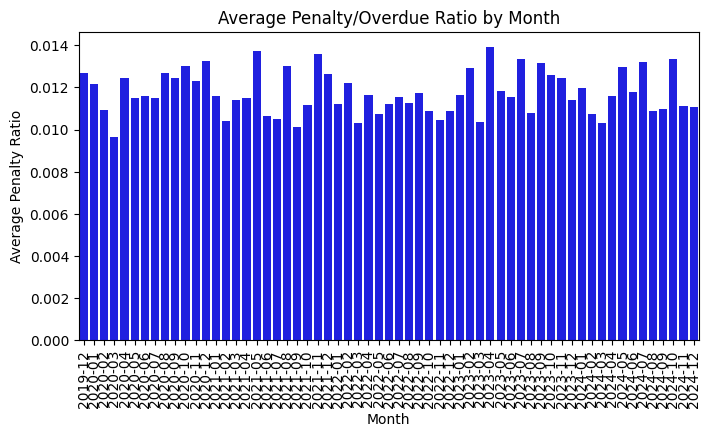


Recovery Rates by Default Reason and Legal Action:
      Default_Reason Legal_Action  Recovery_Amount  Default_Amount  \
0   Business Failure           No         14962918        60275246   
1   Business Failure          Yes         14855675        61650737   
2           Job Loss           No         13068979        57241270   
3           Job Loss          Yes         13766243        56236139   
4  Medical Emergency           No         15495404        62314181   
5  Medical Emergency          Yes         14767756        56769115   
6              Other           No         14931148        62257272   
7              Other          Yes         14071690        60063797   

   Recovery_Rate  
0       0.248243  
1       0.240965  
2       0.228314  
3       0.244794  
4       0.248666  
5       0.260137  
6       0.239830  
7       0.234279  


C:\Users\nshetty7\AppData\Local\Temp\ipykernel_2628\2992817061.py:38: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:green'` for the same effect.

  sns.barplot(data=recovery_by_reason_action,x="Default_Reason",y="Recovery_Rate",hue="Legal_Action",color="green")


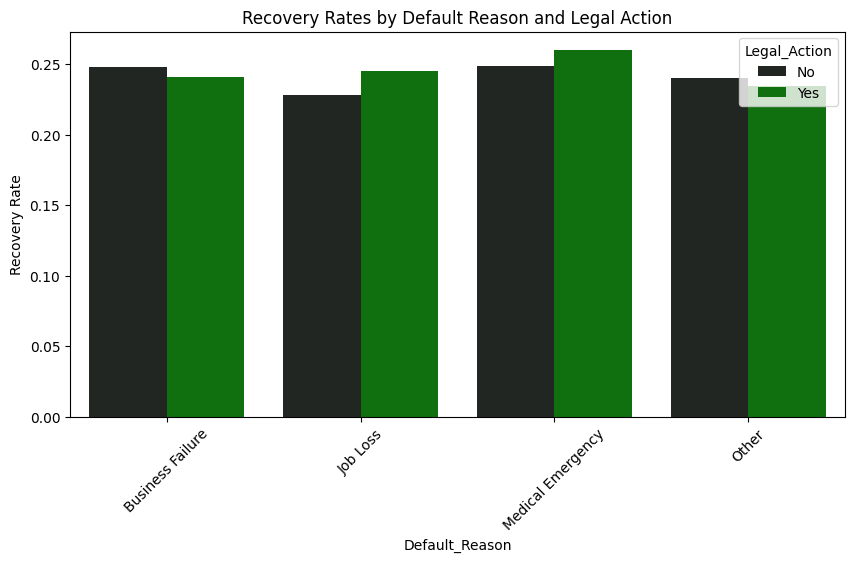


Recovery Rates by Region and Branch:
    index                   Branch_Name     Region  Recovery_Rate
0       0                    Bhakta PLC      South       0.258614
1       1                  Solanki-Shah      South       0.258614
2       2               Viswanathan Ltd      South       0.258614
3       3        Mangal, Kaur and Borde      South       0.258614
4       4                       Sem Inc      South       0.258614
5       5          Saini, Iyer and Sani      South       0.258614
6       6  Zacharia, Srivastava and Sha      South       0.258614
7       7       Wable, Butala and Kakar      South       0.258614
8       8                   Doshi Group      North       0.249495
9       9                     Sani-Kale      North       0.249495
10     10                     Doshi LLC      North       0.249495
11     11   Banik, Subramanian and Mane      North       0.249495
12     12           Bhatti, Rau and Sem      North       0.249495
13     13                    Bath-Bass

In [9]:
# --- 1. Analyze penalty payments and overdue trends ---

# Calculate proportion of overdue to loan amounts as a "penalty ratio"
#-----------------------------------------------------------------------------------------------------------------------------
#loans["Penalty_Ratio"] = loans["Overdue_Amount"] / loans["Loan_Amount"]
loan_customer_branch["Penalty_Ratio"] = loan_customer_branch["Overdue_Amount"] / loan_customer_branch["Loan_Amount"]
#-----------------------------------------------------------------------------------------------------------------------------

penalty_trends = (
    loan_customer_branch.groupby("Month", observed=True)["Penalty_Ratio"]
    .mean()
    .reset_index()
    .sort_values("Month")
)
print("\nPenalty/Overdue Trends by Month:")
print(penalty_trends)

plt.figure(figsize=(8, 4))
sns.barplot(data=penalty_trends, x="Month", y="Penalty_Ratio", color="blue")
plt.title("Average Penalty/Overdue Ratio by Month")
plt.xticks(rotation=90)
plt.ylabel("Average Penalty Ratio")
plt.show()


# --- 2. Evaluate recovery rates by Default_Reason and Legal_Action ---
recovery_by_reason_action = (
    defaults.groupby(["Default_Reason", "Legal_Action"], observed=True)[["Recovery_Amount", "Default_Amount"]]
    .sum()
    .reset_index()
)
recovery_by_reason_action["Recovery_Rate"] = (recovery_by_reason_action["Recovery_Amount"] / recovery_by_reason_action["Default_Amount"])

print("\nRecovery Rates by Default Reason and Legal Action:")
print(recovery_by_reason_action)

plt.figure(figsize=(10, 5))
sns.barplot(data=recovery_by_reason_action,x="Default_Reason",y="Recovery_Rate",hue="Legal_Action",color="green")
plt.title("Recovery Rates by Default Reason and Legal Action")
plt.xticks(rotation=45)
plt.ylabel("Recovery Rate")
plt.show()


# --- 3. Compare recovery rates across regions and branches ---

branch_recovery_rate_region=branch_recovery_rate_df.merge(branches[["Branch_Name","Region"]], on = "Branch_Name" , how = "left")

print("\nRecovery Rates by Region and Branch:")
print(branch_recovery_rate_region[["Branch_Name", "Region", "Recovery_Rate"]].reset_index())

8. EMI Analysis
- Analyze the relationship between EMI amounts and default probabilities.
- Identify thresholds for EMI amounts where defaults are most likely.
- Compare EMI trends across loan types.


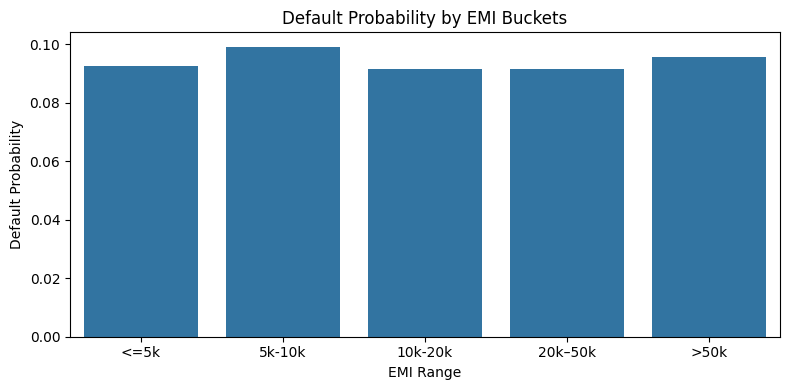


Default rate by EMI ranges:
   EMI_Amount  Default_Flag
0       <=5k      0.092573
1     5k-10k      0.099042
2    10k-20k      0.091562
3    20k–50k      0.091390
4       >50k      0.095601


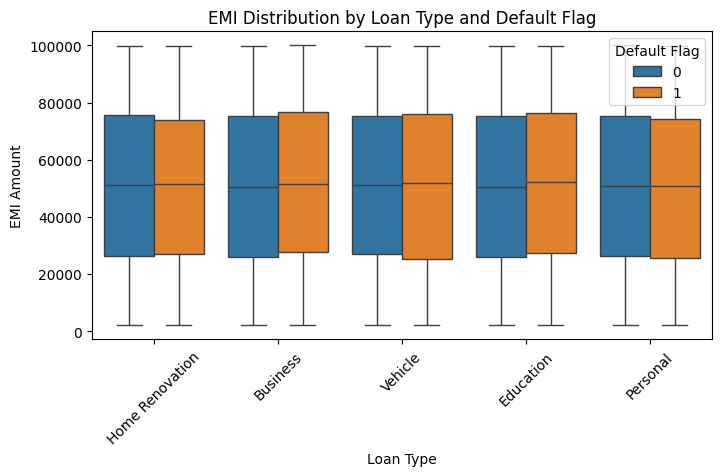

In [10]:
# Group by EMI bins
bins = [0, 5000, 10000, 20000, 50000, loans["EMI_Amount"].max()]
labels = ["<=5k", "5k-10k", "10k-20k", "20k–50k", ">50k"]

# Create EMI buckets using cut
#-----------------------------------------------------------------------------------------------------------------------------
#emi_bins = pd.cut(loans["EMI_Amount"], bins=bins, labels=labels, include_lowest=True)
emi_bins = pd.cut(loan_customer_branch["EMI_Amount"], bins=bins, labels=labels, include_lowest=True)
#-----------------------------------------------------------------------------------------------------------------------------

# 1. Relationship between EMI amounts and default probabilities.

#-----------------------------------------------------------------------------------------------------------------------------
#emi_default_rate = loans.groupby(emi_bins,observed=True)["Default_Flag"].mean().reset_index()
emi_default_rate = loan_customer_branch.groupby(emi_bins,observed=True)["Default_Flag"].mean().reset_index()
#-----------------------------------------------------------------------------------------------------------------------------

plt.figure(figsize=(8, 4))
sns.barplot(data=emi_default_rate, x="EMI_Amount", y="Default_Flag")
plt.title("Default Probability by EMI Buckets")
plt.xlabel("EMI Range")
plt.ylabel("Default Probability")
plt.tight_layout()
plt.show()

# 2. Identify thresholds for EMI amounts where defaults are most likely.

print("\nDefault rate by EMI ranges:\n", emi_default_rate)

# --- 3. Compare EMI trends across loan type 

loan_apps = loan_customer_branch.merge(applications[["Customer_ID","Loan_Purpose","Application_ID","Application_Date","Approval_Date","Processing_Fee","Approval_Status","Rejection_Reason"]],
    on=["Customer_ID"], 
    how="left"
)

if "Loan_Purpose" in loan_apps.columns:
    plt.figure(figsize=(8, 4))
    #-----------------------------------------------------------------------------------------------------------------------------
    #sns.boxplot(data=loan_customer, x="Loan_Status", y="EMI_Amount", hue="Default_Flag")
    sns.boxplot(data=loan_apps, x="Loan_Purpose", y="EMI_Amount", hue="Default_Flag")
    #-----------------------------------------------------------------------------------------------------------------------------
    plt.legend(title="Default Flag", loc="upper right")
    plt.title("EMI Distribution by Loan Type and Default Flag")
    plt.xlabel("Loan Type")
    plt.ylabel("EMI Amount")
    plt.xticks(rotation=45)
    plt.show()


9. Loan Application Insights
- Calculate approval and rejection rates for loan applications.
- Identify the most common reasons for loan rejection.
- Compare application processing fees between approved and rejected applications.

Approval / Rejection Rates (%):
Approval_Status
Approved    84.75
Rejected    15.25
Name: count, dtype: float64


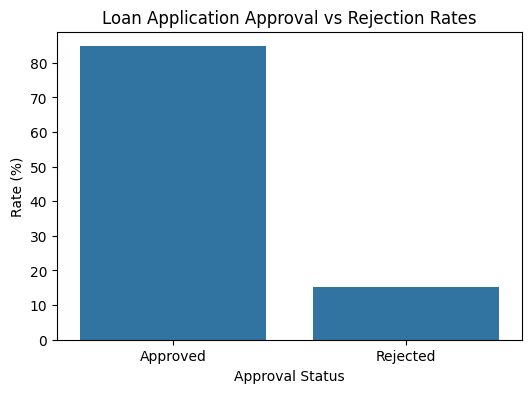


Top Rejection Reasons:
Rejection_Reason
Low Credit Score        4297
Incomplete Documents    4204
Insufficient Income     4099
Name: count, dtype: int64

Processing Fee Comparison (by Approval Status):
                   count         mean          std    min     25%     50%  \
Approval_Status                                                             
Approved         70000.0  5252.395014  2741.573413  500.0  2895.0  5256.0   
Rejected         12600.0  5255.141587  2721.010522  500.0  2897.5  5271.0   

                    75%      max  
Approval_Status                   
Approved         7626.0  10000.0  
Rejected         7602.0   9998.0  


In [11]:
# --- 1. Calculate approval and rejection rates ---
approval_counts = applications["Approval_Status"].value_counts()
total_apps = len(applications)
approval_rates = (approval_counts / total_apps * 100).round(2)

print("Approval / Rejection Rates (%):")
print(approval_rates)

# --- Plot approval vs rejection rates ---
plt.figure(figsize=(6, 4))
sns.barplot(x=approval_rates.index, y=approval_rates.values)
plt.title("Loan Application Approval vs Rejection Rates")
plt.xlabel("Approval Status")
plt.ylabel("Rate (%)")
plt.show()

# --- 2. Identify most common reasons for loan rejection ---
rejection_reasons = (applications.loc[applications["Approval_Status"].str.lower() == "rejected", "Rejection_Reason"].value_counts())
print("\nTop Rejection Reasons:")
print(rejection_reasons.head(10))

# --- 3. Compare processing fees between approved and rejected applications ---
fee_comparison = (applications.groupby("Approval_Status")["Processing_Fee"].describe())
print("\nProcessing Fee Comparison (by Approval Status):")
print(fee_comparison)

10. Recovery Effectiveness
- Determine the effectiveness of recovery efforts by calculating the ratio of Recovery_Amount to Default_Amount.
- Compare recovery rates for defaults with and without legal actions.
- Analyze branch-wise recovery performance.


In [12]:
# --- 1. Calculate overall recovery effectiveness ---
default_loan_customer_branch["Recovery_Rate"] = default_loan_customer_branch["Recovery_Amount"] / default_loan_customer_branch["Default_Amount"]
print("Overall Recovery Rate (mean):", default_loan_customer_branch["Recovery_Rate"].mean().round(2))

# --- 2. Compare recovery rates with and without legal actions ---
if "Legal_Action" in default_loan_customer_branch.columns:
    legal_recovery = (default_loan_customer_branch.groupby("Legal_Action")["Recovery_Rate"].mean().reset_index())
    print("\nRecovery Rates by Legal Action:")
    print(legal_recovery)

# --- 3. Analyze branch-wise recovery performance ---

#branch_recovery = None
if "Branch_Name" in default_loan_customer_branch.columns:
    branch_recovery = default_loan_customer_branch.groupby("Branch_Name")["Recovery_Rate"].mean().sort_values(ascending=False).reset_index()
    # --- Plot top 10 branches ---
    print("\nBranch-wise Average Recovery Rate:")
    top_branches = branch_recovery.head(10)
    print(top_branches)


Overall Recovery Rate (mean): 0.4

Recovery Rates by Legal Action:
  Legal_Action  Recovery_Rate
0           No       0.398896
1          Yes       0.397187

Branch-wise Average Recovery Rate:
                    Branch_Name  Recovery_Rate
0                      Bawa Inc       0.447717
1                   Badal Group       0.447717
2            Chawla-Subramanian       0.447717
3       Borah, Comar and Bhalla       0.447717
4              Sachdev-Banerjee       0.447717
5    Uppal, Sankaran and Thaker       0.447717
6  Malhotra, Boase and Malhotra       0.447717
7         Raja, Ratta and Sathe       0.447717
8                     Gala-Gara       0.447717
9                     Garde PLC       0.447717


11. Loan Disbursement Efficiency
- Analyze the time from application to loan disbursement and identify bottlenecks.
- Compare average processing times across branches.
- Evaluate disbursement trends by loan purpose and region.

In [13]:
# --- 1. Calculate time from application to disbursement ---

# Compute processing time in days
loan_apps["Processing_Time_Days"] = (loan_apps["Disbursal_Date"] - loan_apps["Application_Date"]).dt.days

print("\nOverall average processing time (days):", loan_apps["Processing_Time_Days"].mean().round(2))

# --- 2. Compare average processing times across branches ---
if "Branch_Name" in loan_apps.columns:
    branch_times = (loan_apps.groupby("Branch_Name")["Processing_Time_Days"].mean().sort_values(ascending = False).reset_index()
    )

    print("\nAverage processing time by branch (days):")
    print(branch_times.head(20))   # top 10 fastest branches


# --- 3. Evaluate disbursement trends by loan purpose and region ---
if "Loan_Purpose" in loan_apps.columns:
    purpose_times = (loan_apps.groupby("Loan_Purpose")["Processing_Time_Days"].mean().sort_values().reset_index())
    print("\nAverage processing time by loan purpose:")
    print(purpose_times)

if "Region" in loan_apps.columns:
    region_times = (loan_apps.groupby("Region")["Processing_Time_Days"].mean().sort_values().reset_index())
    print("\nAverage processing time by region:")
    print(region_times)


Overall average processing time (days): 173.13

Average processing time by branch (days):
                     Branch_Name  Processing_Time_Days
0                     Apte Group            186.084855
1    Banik, Subramanian and Mane            186.084855
2                    Doshi Group            186.084855
3                     Bath-Bassi            186.084855
4            Bhatti, Rau and Sem            186.084855
5                    Dhingra Ltd            186.084855
6        Dada, Chander and Bhatt            186.084855
7           Lad, Wali and Ramesh            186.084855
8                    Madan-Lanka            186.084855
9                      Doshi LLC            186.084855
10        Khalsa, Mani and Banik            186.084855
11                     Sani-Kale            186.084855
12                      Yogi Ltd            186.084855
13                    Vasa Group            186.084855
14                      Loke Inc            178.686085
15             Mahajan-Zachar

12. Profitability Analysis
- Calculate the total interest income generated across all loans.
- Identify the most profitable loan purposes based on interest earnings.
- Compare profitability metrics for branches across regions.


In [14]:
# ---------interest income per loan
if "Loan_Amount" in loan_apps.columns and "Interest_Rate" in loan_apps.columns:
    if loan_apps["Loan_Term"].max() > 12:
        term_years = loan_apps["Loan_Term"] / 12
    else:
        term_years = loan_apps["Loan_Term"] 
      
    loan_apps["Interest_Income"] = loan_apps["Loan_Amount"] * (loan_apps["Interest_Rate"] / 100) * term_years
else:
    loan_apps["Interest_Income"].fillna(0)
    
# --- 1.Calculate the total interest income generated across all loans.------
total_interest_income = loan_apps["Interest_Income"].sum(skipna=True)
print("\nTotal interest income across all loans:", round(total_interest_income, 2))


# --- 2. Identify the most profitable loan purposes based on interest earnings. ---
if "Loan_Purpose" in loan_apps.columns:
    purpose_profit = (loan_apps.groupby("Loan_Purpose")["Interest_Income"].sum().sort_values(ascending=False).reset_index())
    #purpose_profit["Interest_Income"] = purpose_profit["Interest_Income"].round(2)
    print("\nMost profitable loan purposes based on interest income:")
    print(purpose_profit.to_string(formatters={"Interest_Income": "{:,.2f}".format}))
    
# --- 3. Profitability metrics for branches across regions ---

branch_profit = (loan_apps.groupby(["Region", "Branch_Name"])["Interest_Income"].sum().sort_values(ascending=False).reset_index())
print("\nBranch profitability across regions:")
print(branch_profit.to_string(formatters={"Interest_Income": "{:,.2f}".format}))


Total interest income across all loans: 735984302502.03

Most profitable loan purposes based on interest income:
      Loan_Purpose    Interest_Income
0         Business 151,763,632,978.14
1          Vehicle 148,815,978,066.60
2  Home Renovation 145,547,831,030.72
3        Education 145,245,991,568.73
4         Personal 144,610,868,857.83

Branch profitability across regions:
       Region                   Branch_Name   Interest_Income
0        West                      Kaul Inc 14,894,238,664.54
1        West                     Kar-Jaggi 14,894,238,664.54
2        West                      Arya Ltd 14,894,238,664.54
3        West              Contractor-Sodhi 14,894,238,664.54
4        West          Dhar, Kant and Madan 14,894,238,664.54
5        West          Kapadia-Ramakrishnan 14,894,238,664.54
6        East                  Grover Group 14,891,560,625.35
7        East                 Chawla-Tandon 14,891,560,625.35
8        East                     Kara-Bahl 14,891,560,625.35


13. Geospatial Analysis
- Map the distribution of active loans across regions.
- Compare default rates across different geographic regions.
- Visualize the loan disbursement trends for rural vs. urban areas.


Active loan distribution by region:
      Region  Active_Loans
2      North        210574
0    Central        148490
1       East        122528
4      South        119592
5       West         89406
3  Northeast         59776


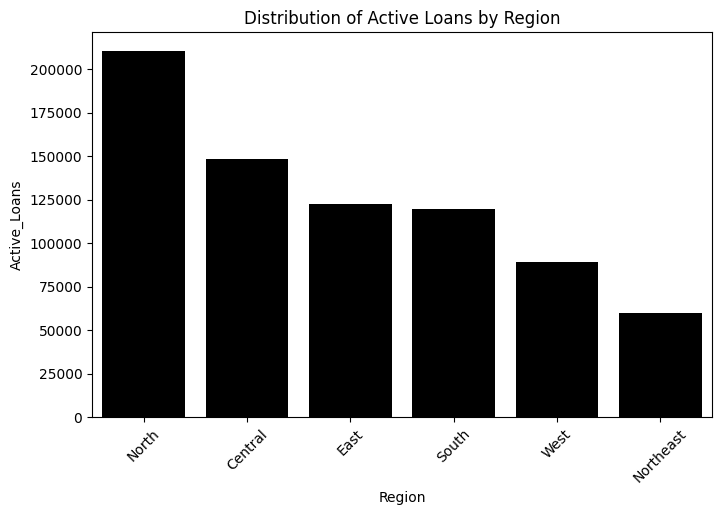


Default rates by region:
      Region  Default_Rate
4      South      0.100408
5       West      0.099322
0    Central      0.095831
3  Northeast      0.095824
2      North      0.089090
1       East      0.088992


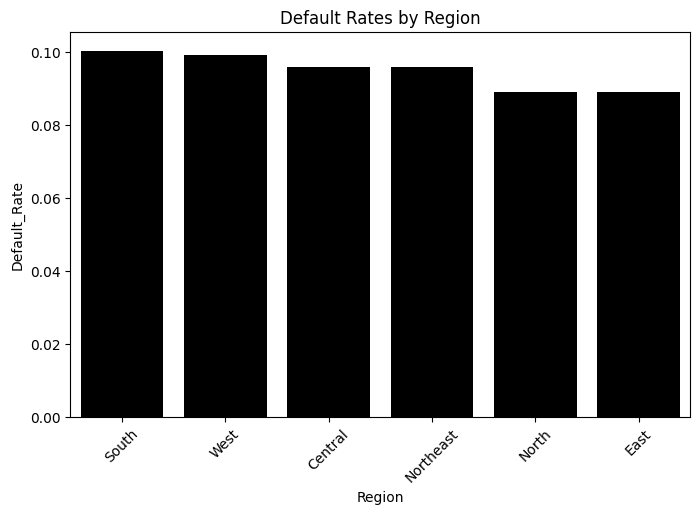


Loan disbursement trends (rural vs. urban):
       Month Area_Type  Loan_Amount
7    2020-03     Urban  30992344988
51   2022-01     Urban  30633387822
65   2022-08     Urban  30371555882
105  2024-04     Urban  30340444794
41   2021-08     Urban  30314098514


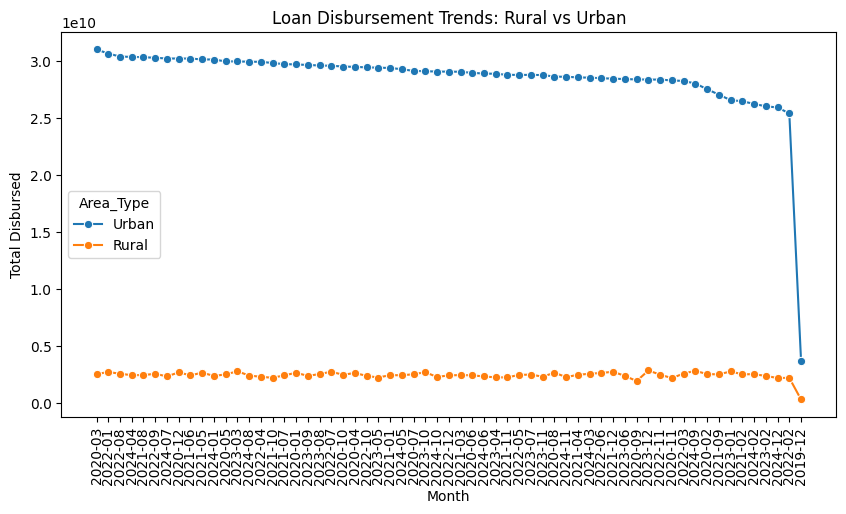

In [15]:
# --- Assumption as NorthEast → Rural, Others → Urban ---
if "Region" in loan_customer_branch.columns:
    loan_customer_branch["Area_Type"] = loan_customer_branch["Region"].apply(lambda r: "Rural" if str(r).strip().lower() == "northeast" else "Urban")
else:
    loan_customer_branch["Area_Type"] = "Unknown"


# --- 1. Distribution of active loans across regions ---
region_counts = (loan_customer_branch.groupby("Region")["Loan_ID"].count().reset_index(name="Active_Loans").sort_values("Active_Loans", ascending=False))
print("\nActive loan distribution by region:")
print(region_counts)

plt.figure(figsize=(8, 5))
sns.barplot(data=region_counts, x="Region", y="Active_Loans", color="black")
plt.title("Distribution of Active Loans by Region")
plt.xticks(rotation=45)
plt.show()


# --- 2. Compare default rates across regions ---
if "Default_Flag" in loan_customer_branch.columns and "Region" in loan_customer_branch.columns:
    region_defaults = (
        loan_customer_branch.groupby("Region")["Default_Flag"]
        .mean()
        .reset_index(name="Default_Rate")
        .sort_values("Default_Rate", ascending=False)
    )
    print("\nDefault rates by region:")
    print(region_defaults)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=region_defaults, x="Region", y="Default_Rate", color="black")
    plt.title("Default Rates by Region")
    plt.xticks(rotation=45)
    plt.show()
    
# --- 3. Loan disbursement trends for rural vs. urban areas ---
if "Area_Type" in loan_customer_branch.columns and "Disbursal_Date" in loan_customer_branch.columns:

    rural_urban_trend = (loan_customer_branch.groupby(["Month", "Area_Type"])["Loan_Amount"].sum().reset_index().sort_values("Loan_Amount", ascending=False))

    print("\nLoan disbursement trends (rural vs. urban):")
    print(rural_urban_trend.head())
    
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=rural_urban_trend, x="Month", y="Loan_Amount", hue="Area_Type", marker="o")
    plt.title("Loan Disbursement Trends: Rural vs Urban")
    plt.xlabel("Month")
    plt.ylabel("Total Disbursed")
    plt.xticks(rotation=90)
    plt.show()


14. Default Trends
- Analyze the number of defaults over time to identify patterns.
- Calculate the average default amount for different loan purposes.
- Compare default rates across customer income categories.



Defaults over time (first few rows):
       Month  Default_Count
0 2021-01-01            164
1 2021-02-01            171
2 2021-03-01            189
3 2021-04-01            196
4 2021-05-01            195


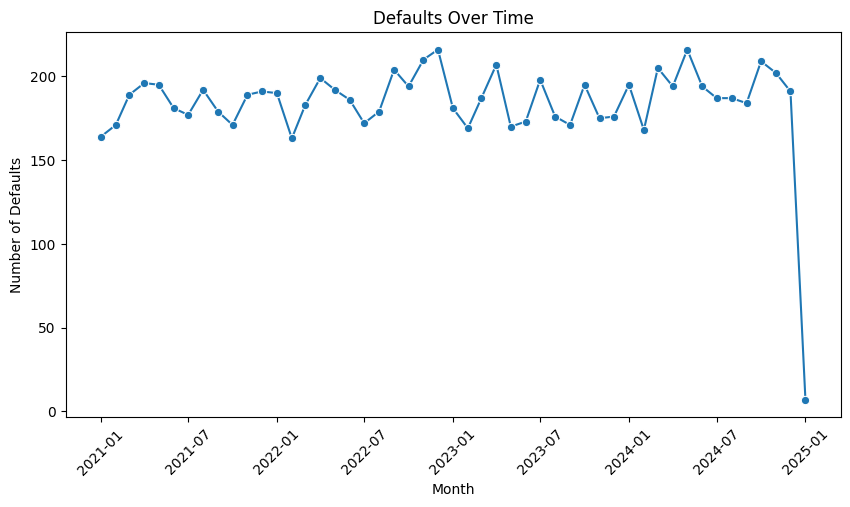


Average default amount by loan purpose:
      Loan_Purpose  Default_Amount
0        Education    53669.435741
1  Home Renovation    53090.559524
2         Business    53021.308498
3          Vehicle    52783.094675
4         Personal    52076.262275


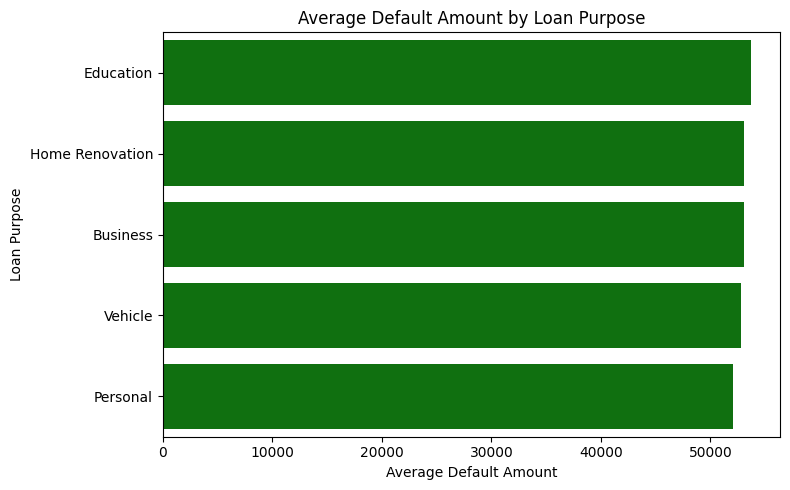


Default rates by income category:


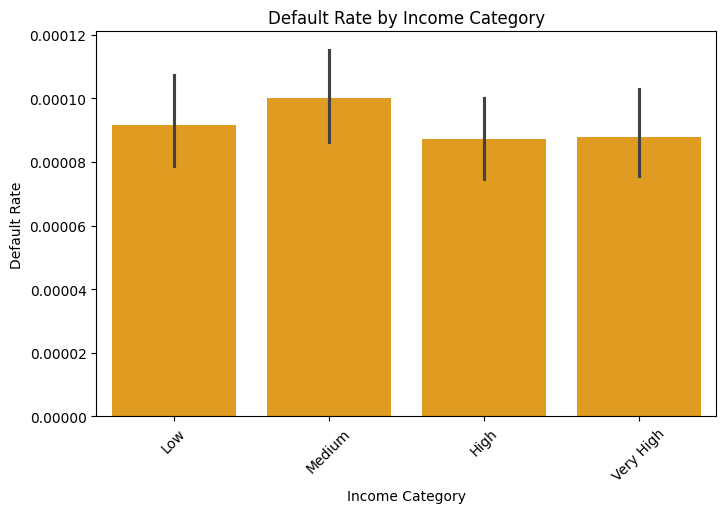

In [16]:
# --- 1. Analyze number of defaults over time ---

# Extract Month or Year-Month for trend analysis
defaults["Month"] = defaults["Default_Date"].dt.to_period("M").dt.to_timestamp()

# Count defaults per month
defaults_over_time = (defaults.groupby("Month")["Default_ID"].count().reset_index(name="Default_Count"))

print("\nDefaults over time (first few rows):")
print(defaults_over_time.head())

plt.figure(figsize=(10, 5))
sns.lineplot(data=defaults_over_time, x="Month", y="Default_Count", marker="o")
plt.title("Defaults Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Defaults")
plt.xticks(rotation = 45)
plt.show()


# --- 2. Average default amount for different loan purposes ---
default_apps = defaults.merge(applications,on="Customer_ID",how="left")

if "Loan_Purpose" in default_apps.columns:
    avg_default_by_purpose = (default_apps.groupby("Loan_Purpose")["Default_Amount"].mean().sort_values(ascending=False).reset_index())
    print("\nAverage default amount by loan purpose:")
    print(avg_default_by_purpose)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=avg_default_by_purpose, x="Default_Amount", y="Loan_Purpose", color="green")
    plt.title("Average Default Amount by Loan Purpose")
    plt.xlabel("Average Default Amount")
    plt.ylabel("Loan Purpose")
    plt.tight_layout()
    plt.show()


# --- 3. Compare default rates across customer income categories ---
#Merge defaults with customers to bring income category
default_customers_income = default_customers.merge(customers[["Customer_ID","Annual_Income"]],on ="Customer_ID", how = "left")

default_customers_income["Income_Category"] = pd.cut(default_customers_income["Annual_Income"],bins=4,labels=["Low", "Medium", "High", "Very High"])

# To get rates, you need total customers/loans per category
total_by_income = (default_customers_income.groupby("Income_Category",observed=False)["Customer_ID"].count().reset_index(name="Total_Customers"))

default_rate_by_income = default_customers_income.merge(total_by_income, on="Income_Category", how="left")


# Add a binary Default_Flag to loans
default_rate_by_income["Default_Flag"] = loans["Loan_ID"].isin(defaults["Loan_ID"]).astype(int)

default_rate_by_income["Default_Rate"] = (default_rate_by_income["Default_Flag"] / default_rate_by_income["Total_Customers"]).round(3)

print("\nDefault rates by income category:")
#print(default_rate_by_income)

plt.figure(figsize=(8, 5))
sns.barplot(data=default_rate_by_income, x="Income_Category", y="Default_Rate", color="orange")
plt.title("Default Rate by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Default Rate")
plt.xticks(rotation = 45)
plt.show()

15. Branch Efficiency
- Calculate the average loan disbursement time for each branch.
- Identify branches with the highest number of rejected applications.
- Compare branch efficiency based on customer satisfaction metrics (if available).

In [17]:
# --- 1. Average loan disbursement time for each branch ---

# Average loan disbursement time per branch
avg_disbursement_time = (
    loan_apps.groupby("Branch_ID")["Processing_Time_Days"]
    .mean()
    .reset_index()
    .rename(columns={"Processing_Time_Days": "Avg_Disbursement_Time_Days"})
)

print("---1.Average loan disbursement time per branch ---")
print(avg_disbursement_time.head())


# --- 2. Identify branches with the highest number of rejected applications ---
if "Approval_Status" in applications.columns:
    rejected_counts = (loan_apps.loc[loan_apps["Approval_Status"].str.lower() == "rejected"].groupby("Branch_ID")["Application_ID"].count().reset_index(name="Rejected_Count")
        .sort_values("Rejected_Count", ascending=False)
    )

    print("---2.Branches with highest number of rejected applications---")
    print(rejected_counts)
    
# --- 3. Compare branch efficiency based on customer satisfaction metrics (if available). ---
print("---3.Branch efficiency based on Customer satisfaction---")
print("Customer_Satisfication_Score is not available.")


---1.Average loan disbursement time per branch ---
  Branch_ID  Avg_Disbursement_Time_Days
0      B001                  166.243471
1      B002                  169.821862
2      B003                  159.151092
3      B004                  169.821862
4      B005                  173.413848
---2.Branches with highest number of rejected applications---
   Branch_ID  Rejected_Count
0       B001            2789
9       B010            2789
11      B012            2789
41      B042            2789
26      B027            2789
19      B020            2789
29      B030            2743
1       B002            2743
15      B016            2743
3       B004            2743
21      B022            2743
35      B036            2743
46      B047            2743
42      B043            2743
17      B018            2720
37      B038            2720
40      B041            2720
31      B032            2720
48      B049            2648
49      B050            2648
8       B009            2648
39      B

16. Time-Series Analysis
- Analyze monthly loan disbursement trends over the last 5 years.
- Identify seasonal patterns in loan applications and disbursements.
- Compare monthly default rates across regions.

In [18]:
# --- Filter for last 5 years  ---
current_year = pd.Timestamp.now().year
#loans_last_5yrs = loans[loans["Disbursal_Date"].dt.year >= (current_year - 5)].copy()
loans_last_5yrs = loans_customers[loans_customers["Disbursal_Date"].dt.year >= (current_year - 5)].copy()


# Extract Year-Month for grouping
loans_last_5yrs["YearMonth"] = loans_last_5yrs["Disbursal_Date"].dt.to_period("M").dt.to_timestamp()


print("---1. Monthly loan disbursement trends over the last 5 years---")
if "Loan_Amount" in loans_last_5yrs.columns:
    monthly_disbursement = (loans_last_5yrs.groupby("YearMonth", observed=True)["Loan_Amount"].sum().reset_index())
    print(monthly_disbursement)
else:
    print("Column Loan_Amount not found in loans data.")


print("\n--- 2. Seasonal patterns in loan applications and disbursements ---")
# Extracted the month number and name
loans_last_5yrs["Month"] = loans_last_5yrs["Disbursal_Date"].dt.month_name()
#loans_last_5yrs.loc[:, "Month"] = loans_last_5yrs["Disbursal_Date"].dt.month_name()
seasonal_disbursement = (loans_last_5yrs.groupby("Month", observed=True)["Loan_Amount"].sum().reset_index().sort_values(by="Loan_Amount", ascending=False))
print(seasonal_disbursement)


print("\n--- 3. Monthly default rates across regions ---")

if "Region" in loans_last_5yrs.columns and "Default_Flag" in loans_last_5yrs.columns:
    monthly_default_rates = (
        loans_last_5yrs.groupby(["YearMonth", "Region"], observed=True)["Default_Flag"]
        .mean()
        .reset_index()
        .rename(columns={"Default_Flag": "Default_Rate"})
    )
    print(monthly_default_rates)
else:
    print("Columns Region and/or Default_Flag not found in loans data.")

---1. Monthly loan disbursement trends over the last 5 years---
    YearMonth  Loan_Amount
0  2020-01-01   3908302834
1  2020-02-01   3621088694
2  2020-03-01   4031554268
3  2020-04-01   3817013578
4  2020-05-01   3870491103
5  2020-06-01   3724997124
6  2020-07-01   3766777788
7  2020-08-01   3821911676
8  2020-09-01   3609549239
9  2020-10-01   3786398487
10 2020-11-01   3611669266
11 2020-12-01   3983625463
12 2021-01-01   3895671240
13 2021-02-01   3523161389
14 2021-03-01   3760219149
15 2021-04-01   3725137849
16 2021-05-01   3951296695
17 2021-06-01   3822306295
18 2021-07-01   3888950426
19 2021-08-01   3873532000
20 2021-09-01   3599288291
21 2021-10-01   3805692685
22 2021-11-01   3682295505
23 2021-12-01   3800058008
24 2022-01-01   4051642124
25 2022-02-01   3304821248
26 2022-03-01   3736386664
27 2022-04-01   3821905786
28 2022-05-01   3755695976
29 2022-06-01   3791037985
30 2022-07-01   3904074393
31 2022-08-01   3999301404
32 2022-09-01   3875546852
33 2022-10-01   37

17. Customer Behavior Analysis
- Categorize customers based on their repayment behavior (e.g., always on time, occasional defaulters, frequent defaulters).
- Analyze patterns in loan approval and rejection reasons segmented by customer demographics.
- Identify high-value customers with consistent repayment histories.

In [19]:

print("\n--- 1. Categorize customers based on repayment behavior ---")
if "Customer_ID" in loans_customers.columns and "Default_Flag" in loans_customers.columns:
    # Count number of loans and defaults per customer
    
    repayment_stats = (
        loans_customers.groupby("Customer_ID", observed=True)["Default_Flag"]
        .agg(["count", "sum"])
        .reset_index()
        .rename(columns={"count": "Total_Loans", "sum": "Defaults"})
    )
    
    repayment_stats["Default_Ratio"] = repayment_stats["Defaults"] / repayment_stats["Total_Loans"]

    repayment_stats["Repayment_Behavior"] = pd.cut(
        repayment_stats["Default_Ratio"],
        bins=3,
        labels=["Always on Time", "Occasional Defaulter", "Frequent Defaulter"]
    )
    print(repayment_stats["Repayment_Behavior"].value_counts())
    
else:
    print("Required columns (Customer_ID, Default_Flag) not found in loans data.")


print("\n--- 2. Analyze patterns in loan approval/rejection reasons by customer demographics ---")
if {"Customer_ID", "Approval_Status", "Rejection_Reason"}.issubset(applications.columns) and "Customer_ID" in customers.columns:
    apps_customer = applications.merge(customers, on="Customer_ID", how="left")
    approval_patterns = (
        apps_customer.groupby(["Rejection_Reason", "Approval_Status"], observed=True)["Customer_ID"]
        .count()
        .reset_index(name="Count")
        .sort_values(by="Count", ascending=False)
    )
    print(approval_patterns.head())
else:
    print("Required columns for approval/rejection patterns not found.")

    
print("\n--- 3. Identify high-value customers with consistent repayment histories ---")
# This assumes you have Loan_Amount and Default_Flag per loan
if {"Customer_ID", "Loan_Amount", "Default_Flag"}.issubset(loans_customers.columns):
    customer_value = (
        loans_customers.groupby("Customer_ID", observed=True)[["Loan_Amount", "Default_Flag"]] 
        .sum() 
        .rename(columns={"Loan_Amount": "Total_Loan_Amount", "Default_Flag": "Defaults"}) 
        .reset_index()
    )

    high_value_customers = customer_value[
        (customer_value["Total_Loan_Amount"] > customer_value["Total_Loan_Amount"].quantile(0.75)) &
        (customer_value["Defaults"] == 0)
    ]
    print(high_value_customers[high_value_customers["Defaults"]==0])
else:
    print("Required columns (Customer_ID, Loan_Amount, Default_Flag) not found in loans data.")


--- 1. Categorize customers based on repayment behavior ---
Repayment_Behavior
Always on Time          45068
Occasional Defaulter     3009
Frequent Defaulter       2599
Name: count, dtype: int64

--- 2. Analyze patterns in loan approval/rejection reasons by customer demographics ---
       Rejection_Reason Approval_Status  Count
2      Low Credit Score        Approved  70000
3      Low Credit Score        Rejected   4297
0  Incomplete Documents        Rejected   4204
1   Insufficient Income        Rejected   4099

--- 3. Identify high-value customers with consistent repayment histories ---
      Customer_ID  Total_Loan_Amount  Defaults
0         C000003            6194007         0
1         C000004           11159729         0
3         C000007            7678817         0
7         C000013           19829940         0
9         C000017            6863821         0
...           ...                ...       ...
50660     C069977            7586778         0
50662     C069982         

18. Risk Assessment
- Develop a risk matrix for loan products based on Default_Amount, Loan_Term, and Interest_Rate.
- Rank loan types by risk level and suggest mitigation strategies.
- Analyze high-risk customer segments by credit score and income.

In [20]:
# --- 1. Build a simple risk matrix for loan products ---
# Compute average risk factors per loan type
default_loan_interest = default_loan.merge(loans[["Loan_ID","Loan_Term","Interest_Rate"]] , on =["Loan_ID"],how = "left")
# --- consider loan purpose as loan type
default_loan_apps =  default_loan_interest.merge(applications[["Loan_ID","Loan_Purpose"]] , on = ["Loan_ID"], how ="left")

risk_matrix = (
    default_loan_apps.groupby("Loan_Purpose")[["Default_Amount", "Loan_Term", "Interest_Rate"]]
    .mean()
    .reset_index()
)

# --- Simple normalization: divide each column by its maximum ---
for col in ["Default_Amount", "Loan_Term", "Interest_Rate"]:
    risk_matrix[col + "_Norm"] = risk_matrix[col] / risk_matrix[col].max()
    

# Normalize each metric within 0 to 1 scale
for col in ["Default_Amount", "Loan_Term", "Interest_Rate"]: 
    risk_matrix[col + "_Norm"] = (risk_matrix[col] - risk_matrix[col].min()) / (risk_matrix[col].max() - risk_matrix[col].min())

# Assumptions for composite risk score
risk_matrix["Risk_Score"] = (
    risk_matrix["Default_Amount_Norm"] * 0.5
    + risk_matrix["Loan_Term_Norm"] * 0.2
    + risk_matrix["Interest_Rate_Norm"] * 0.3
)
print("\nAverage risk factors per loan type")
print(risk_matrix)

# --- 2. Rank loan types by risk level ---
risk_matrix = risk_matrix.sort_values(by="Risk_Score", ascending=False)
print("\nLoan Types ranked by risk level:")
print(risk_matrix[["Loan_Purpose", "Risk_Score"]])


# --- 3. Identify high-risk customer segments ---
# Define a simple high/low risk cut based on Credit_Score and Income
default_loan_apps_customer = default_loan_apps.merge(customers[["Customer_ID","Annual_Income","Credit_Score"]],on=["Customer_ID"],how= "left")

default_loan_apps_customer["Customer_Risk_Segment"] = "Lower Risk"  # default
default_loan_apps_customer.loc[(default_loan_apps_customer["Credit_Score"] < 600) & (default_loan_apps_customer["Annual_Income"] < default_loan_apps_customer["Annual_Income"].median()), "Customer_Risk_Segment"] = "High Risk - Low Income"
default_loan_apps_customer.loc[(default_loan_apps_customer["Credit_Score"] < 600) & (default_loan_apps_customer["Annual_Income"] >= default_loan_apps_customer["Annual_Income"].median()), "Customer_Risk_Segment"] = "High Risk - High Income"
# Summarize segment counts
segment_summary = default_loan_apps_customer["Customer_Risk_Segment"].value_counts()
print("\nCustomer risk segment distribution:")
print(segment_summary)


Average risk factors per loan type
      Loan_Purpose  Default_Amount  Loan_Term  Interest_Rate  \
0         Business    53261.031433  36.631579      11.042113   
1        Education    53797.758769  36.910523      10.971152   
2  Home Renovation    53038.080028  35.558074      10.929525   
3         Personal    52389.399011  35.923729      10.879117   
4          Vehicle    52671.599578  36.895144      10.993462   

   Default_Amount_Norm  Loan_Term_Norm  Interest_Rate_Norm  Risk_Score  
0             0.618899        0.793749            1.000000    0.768199  
1             1.000000        1.000000            0.564649    0.869395  
2             0.460593        0.000000            0.309262    0.323075  
3             0.000000        0.270365            0.000000    0.054073  
4             0.200375        0.988629            0.701524    0.508371  

Loan Types ranked by risk level:
      Loan_Purpose  Risk_Score
1        Education    0.869395
0         Business    0.768199
4          Veh

19. Time to Default Analysis
- Calculate the average time from loan disbursement to default for overdue loans.
- Identify loan purposes with the shortest time to default.
- Compare the time to default across customer demographics.


In [21]:
# --- 1. Calculate time to default (in days) ---
default_loan_apps_time = default_loan_apps_customer.merge(loans[["Loan_ID","Disbursal_Date"]] , on ="Loan_ID",how ="left")

# Only for loans that actually defaulted (Default_Date not null)
defaulted_loans = default_loan_apps_time[default_loan_apps_customer["Default_Date"].notna()].copy()

# Compute the time to default
defaulted_loans["Time_to_Default"] = (defaulted_loans["Default_Date"] - defaulted_loans["Disbursal_Date"]).dt.days

# Average time to default
avg_time_to_default = defaulted_loans["Time_to_Default"].mean()
print(f"\nAverage time to default (days): {avg_time_to_default:.0f}")


# --- 2. Identify loan purposes with shortest time to default ---
purpose_time_to_default = (defaulted_loans.groupby("Loan_Purpose")["Time_to_Default"].mean().sort_values())

print("\nAverage time to default by loan purpose:")
print(purpose_time_to_default)


# --- 3. Compare time to default across customer demographics ---
# It should have Customer_ID and demographic info (like Region, Employee_Status,Marital Status, etc.)

demographics_merge = defaulted_loans.merge(customers[["Customer_ID","Region", "Employment_Status","Marital_Status"]], on="Customer_ID", how="left")
cust_demo_time_to_default = (
        demographics_merge.groupby(["Region", "Employment_Status","Marital_Status"])["Time_to_Default"]
        .mean()
        .reset_index()
        .sort_values(by="Time_to_Default",ascending = False) 
    )
print("\nAverage time to default by demographics:")
print(cust_demo_time_to_default)


Average time to default (days): 207

Average time to default by loan purpose:
Loan_Purpose
Education          185.538296
Business           196.201754
Home Renovation    197.039660
Vehicle            227.274455
Personal           230.888418
Name: Time_to_Default, dtype: float64

Average time to default by demographics:
       Region Employment_Status Marital_Status  Time_to_Default
48       West     Self-Employed       Divorced       311.633929
31  Northeast     Self-Employed        Married       311.620968
41      South     Self-Employed         Single       294.928000
17       East        Unemployed         Single       286.866142
23      North     Self-Employed         Single       286.679104
32  Northeast     Self-Employed         Single       281.241667
33  Northeast        Unemployed       Divorced       279.942623
12       East     Self-Employed       Divorced       278.618321
35  Northeast        Unemployed         Single       277.380531
29  Northeast          Salaried       

20. Transaction Pattern Analysis
- Identify customers with irregular repayment patterns.
- Analyze penalty payments as a proportion of total transactions.
- Compare transaction amounts for overdue vs. non-overdue loans.

In [22]:
# --- 1. Identify customers with irregular repayment patterns ---

# Example logic: count how often a customer pays less or more than their average EMI
customer_tx = (transactions.groupby("Customer_ID")["Amount"].agg(["mean", "std", "count"]).reset_index()) 

# Flag customers with high variability (std > 50% of mean) 
customer_tx["Irregular_Repayment"] = customer_tx["std"] > (0.5 * customer_tx["mean"])

print("\n---1.Customers with irregular repayment patterns---")
print(customer_tx[customer_tx["Irregular_Repayment"]][["Customer_ID", "count"]])

# --- 2. Analyze penalty payments as proportion of total transactions ---

penalty_summary = (
    transactions[transactions["Payment_Type"] == "Penalty"]  # or "Late Fee"
    .groupby("Customer_ID")["Amount"]
    .sum()
    .reset_index(name="Penalty_Amount")
)

# Merge with total transaction amounts
total_summary = (
    transactions.groupby("Customer_ID")["Amount"]
    .sum()
    .reset_index(name="Total_Amount")
)

penalty_summary = penalty_summary.merge(total_summary, on="Customer_ID", how="right").fillna(0)
penalty_summary["Penalty_Ratio"] = penalty_summary["Penalty_Amount"] / penalty_summary["Total_Amount"]


print("\n----2. Analyze penalty payments as a proportion of total transactions-----")
penalty_payment= penalty_summary.sort_values(by="Penalty_Ratio", ascending=False).head(20)
print(penalty_payment)


# --- 3. Compare transaction amounts for overdue vs non-overdue loans ---
# Merge transactions with loan info for Default_Flag
tx_with_loan = transactions.merge(loans_customers[["Loan_ID", "Default_Flag"]], on="Loan_ID", how="left")

overdue_comparison = (tx_with_loan.groupby("Default_Flag")["Amount"].mean().reset_index().rename(columns={"Transaction_Amount": "Avg_Transaction_Amount"}))

print("\n---3.Average transaction amount by overdue/default status---")
print(overdue_comparison)




---1.Customers with irregular repayment patterns---
      Customer_ID  count
2         C000005      2
3         C000007      8
4         C000008      3
5         C000011     16
6         C000012      7
...           ...    ...
50583     C069991      8
50585     C069994      4
50586     C069997     10
50588     C069999      7
50589     C070000     21

[32826 rows x 2 columns]

----2. Analyze penalty payments as a proportion of total transactions-----
      Customer_ID  Penalty_Amount  Total_Amount  Penalty_Ratio
50584     C069993         23886.0         23886            1.0
23        C000036         15656.0         15656            1.0
8         C000016        140921.0        140921            1.0
27819     C038631         49803.0         49803            1.0
33289     C046147        102084.0        102084            1.0
70        C000105         99518.0         99518            1.0
18722     C026077         88335.0         88335            1.0
6959      C009672          4365.0        